In [1]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot


In [2]:
# Andrej Karpathy

class Value:
    def __init__(self, data, _prev=(), _op='', label='a'):
        self.data = data
        self.grad = 0.0
        self._op = _op
        self._prev = set(_prev)
        self._backward = lambda: None
        self.label=label

    def __add__(self, other):
        out = Value(self.data + other.data, _op='+', _prev=(self, other))

        def _backward():
            self.grad = 1 * out.grad
            other.grad = 1 * out.grad

        out._backward = _backward

        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, _op='*', _prev=(self, other))

        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad

        out._backward = _backward

        return out
    

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for v in reversed(topo):
            v._backward()
    
    def __str__(self):
        return f"Value(data={self.data}, label={self.label})"
    
    def __repr__(self):
        return str(self)

In [3]:
a = Value(4, label='a')
b = Value(-5, label='b')
c = a * b; c.label='c'
d = Value(3, label='d')
e = d + c;e.label='e'
f = Value(-6, label='f')
o = e*f; o.label='o'

In [4]:
o.grad = 1

In [5]:
f.grad = e.data * o.grad
e.grad = f.data * o.grad

In [6]:
c.grad = 1 * e.grad
d.grad = 1 * e.grad

In [7]:
b.grad = a.data * c.grad
a.grad = b.data * c.grad

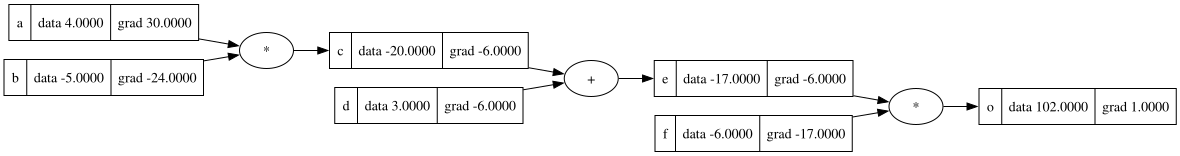

In [8]:
draw_dot(o)

In [9]:
a = Value(4, label='a')
b = Value(-5, label='b')
c = a * b; c.label='c'
d = Value(3, label='d')
e = d + c;e.label='e'
f = Value(-6, label='f')
o = e*f; o.label='o'

In [10]:
o.backward()

In [11]:
o.grad = 1

In [12]:
o._backward()

In [13]:
f._backward()
e._backward()

In [14]:
d._backward()
c._backward()

In [15]:
a._backward()
b._backward()

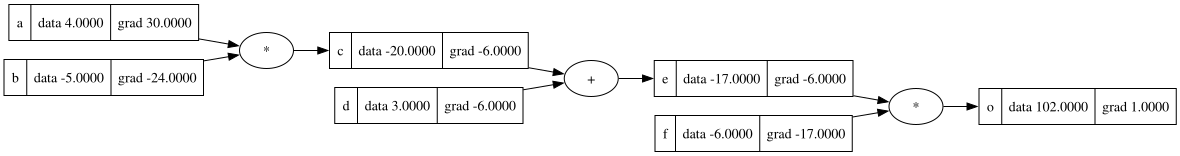

In [16]:
draw_dot(o)

In [17]:
a = Value(4, label='a')
b = Value(-5, label='b')
c = a * b; c.label='c'
d = Value(3, label='d')
e = d + c;e.label='e'
f = Value(-6, label='f')
o = e*f; o.label='o'

In [18]:
o.backward()

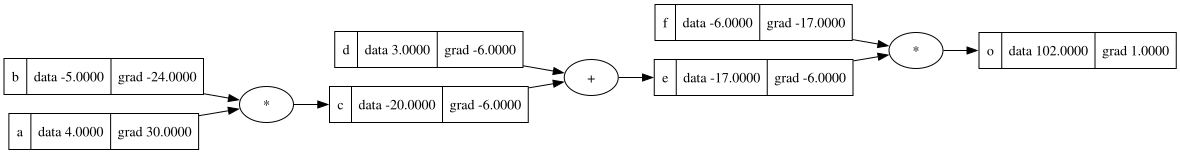

In [19]:
draw_dot(o)

In [21]:
import torch
import numpy as np

In [22]:
# Autograd Engine

X = torch.tensor([[1, 2], [3, 4]], dtype=torch.float)
W = torch.tensor([[11, 21], [31, 41]], dtype=torch.float, requires_grad=True)

In [23]:
c = X @ W

In [24]:
o = torch.sum(c)

In [25]:
o

tensor(560., grad_fn=<SumBackward0>)

In [26]:
W.grad

In [27]:
o.backward()

In [28]:
W.grad

tensor([[4., 4.],
        [6., 6.]])